# Fuzzy Systems and Evolutionary Computing Laboratory Project

**OUTLINE OF THE PROJECT:**

* Install the needed libraries
* Extend the softpy library by creating a new class AlphaFuzzySet
* Plotting of the Fuzzy Sets and general inspection
* Implementation of the class AlphaFuzzyCombination
* Plotting of the resulting Fuzzy Sets

THE IMPORTANCE OF ALPHA CUTS IN FUZZY SET THEORY:

Alpha cuts (α-cuts) are a fundamental tool in fuzzy set theory, representing crisp sets derived from fuzzy sets for a given α level. An α-cut of a fuzzy set includes all elements whose membership degrees are greater than or equal to α (instead, a strict alpha-cut includes the elements whose membership is only greater than alpha).

Combining fuzzy sets is a common operation that results in a new fuzzy set representing the combination of the original sets.

INSTALL THE NEEDED LIBRARIES

In [ ]:
!pip install softpy

from __future__ import annotations
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from softpy.fuzzy.fuzzyset import *
from softpy.fuzzy.operations import *
#from softpy import ContinuousFuzzySet
import numpy as np
import scipy as sp
#import matplotlib.image as mpimg
#from scipy import integrate

In [ ]:
class FuzzySet(ABC):
    '''Abstract Class for a generic fuzzy set'''
    @abstractmethod
    def __call__(self, arg) -> np.number:
        pass

    @abstractmethod
    def __getitem__(self, alpha):
        pass

    @abstractmethod
    def fuzziness(self) -> np.number:
        pass

    @abstractmethod
    def hartley(self) -> np.number:
        pass

class ContinuousFuzzySet(FuzzySet):
    '''
    Abstract class for a continuous fuzzy set
    Note: each (bounded) continuous fuzzy set has a minimum and maximum elements s.t. their membership degrees are > 0
    Epsilon is used to define an approximation degree for various operations that cannot be implemented exactly
    '''
    min : np.number
    max : np.number
    epsilon = 0.01

    def __getitem__(self, alpha: np.number) -> np.ndarray | tuple:
        '''
        In general, it is not possible to take alpha cuts of continuous fuzzy sets analytically: we need to search
        explicitly for all values whose membership degree is >= alpha. Since it is impossible to look all real numbers,
        we do a grid search where the grid step-size is defined by epsilon
        '''

        if not np.issubdtype(type(alpha), np.number):
            raise TypeError("Alpha should be a float in [0,1], is %s" % type(alpha))

        if alpha < 0 or alpha > 1:
            raise ValueError("Alpha should be in [0,1], is %s" % alpha)

        grid = np.linspace(self.min, self.max, int((self.max - self.min)/self.epsilon))
        vals = np.array([v if self(v) >= alpha else np.nan for v in grid])
        return vals

    def fuzziness(self) -> np.number:
        '''
        As in the case of alpha cuts, it is generally impossible to compute the fuzziness of a continuous fuzzy set
        analytically: thus, we perform a numerical integration of the fuzziness function between the minimum and maximum
        values of the fuzzy set (it internally uses the __call__ method: notice that it is not implemented in ContinuousFuzzySet!)
        '''
        try:
            return self.f
        except AttributeError:
            func_int = lambda x: 0 if (np.abs(x - 0) <= self.epsilon or np.abs(x - 1) <= self.epsilon) else self(x)*np.log(1/self(x)) + (1 - self(x))*np.log2(1/(1-self(x)))
            self.f : np.number = sp.integrate.quad(func_int, self.min, self.max, epsabs=self.epsilon)[0]
            return self.f

    #if not check_valid_fuzzy(collection1):
    #    return "First dictionary does not describe a fuzzy set"
class AlphaFuzzySet(ContinuousFuzzySet):
    def __init__(self, collection):
        if not isinstance(collection, dict) or not all(isinstance(k, (float, int)) and isinstance(v, list) for k, v in collection.items()):
            raise ValueError("Invalid collection format")

        if not self.check_valid_fuzzy(collection):
            raise ValueError("Invalid fuzzy set: alpha-cuts are not properly nested")

        self.collection = collection

        self.min = min(interval[0] for intervals in collection.values() for interval in intervals)
        self.max = max(interval[1] for intervals in collection.values() for interval in intervals)

        super().__init__()

    def __call__(self, x):
        max_alpha = 0.0
        for alpha, intervals in self.collection.items():
            if any(start <= x <= end for start, end in intervals):
                max_alpha = max(max_alpha, alpha)
        return max_alpha

    def __getitem__(self, alpha):
        if alpha not in self.collection:
            raise KeyError(f"α-cut for α = {alpha} not found in the collection")
        return self.collection[alpha]

    def __eq__(self, other):
        if not isinstance(other, AlphaFuzzySet):
            return False
        return self.collection == other.collection

    def fuzziness(self):
        fuzziness = 0.0
        for alpha, intervals in self.collection.items():
            for start, end in intervals:
                fuzziness += (end - start) * alpha
        return fuzziness

    def hartley(self):
        entropy = 0.0
        for alpha, intervals in self.collection.items():
            for start, end in intervals:
                entropy += np.log2(end - start + 1) * alpha
        return entropy

    @staticmethod
    def check_valid_fuzzy(collection):
        alphas = sorted(collection.keys(), reverse=True)

        for i in range(len(alphas) - 1):
            alpha_higher = alphas[i]
            alpha_lower = alphas[i + 1]

            intervals_higher = collection[alpha_higher]
            intervals_lower = collection[alpha_lower]

            for interval_higher in intervals_higher:
                is_subinterval = False
                for interval_lower in intervals_lower:
                    if interval_lower[0] <= interval_higher[0] and interval_higher[1] <= interval_lower[1]:
                        is_subinterval = True
                        break
                if not is_subinterval:
                    return False

        return True


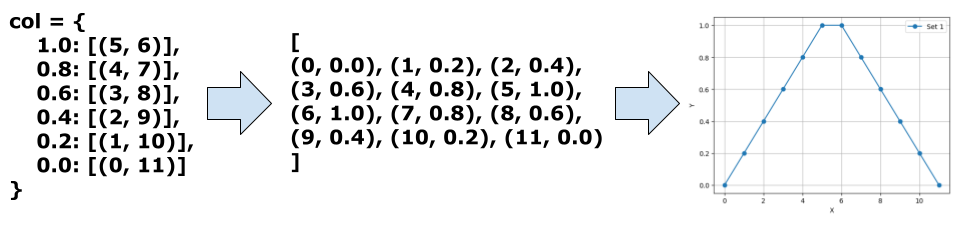

In [ ]:
def extract_coordinates(collection): #Dato un dizionario di tuple, trova i valori delle X e delle Y in ordine sparso (1 ad 1)
    x_coordinates = []
    y_coordinates = []
    for key in collection:
        for tup in collection[key]:
            for x in tup:
                x_coordinates.append(x)
        y_coordinates.append(key)
        #print("Coord x e y func 1", x_coordinates, y_coordinates)
    return x_coordinates, y_coordinates

def combine_coordinates(x_coordinates, y_coordinates): #Dati valori sparsi delle X e delle Y, ritorna le coordinate del singolo punto
    print("Coord x e y", x_coordinates, y_coordinates)
    x_coordinates.sort()
    y_coordinates.reverse()

    y_coordinates = y_coordinates + y_coordinates[::-1]

    coords = [(x, y) for x, y in zip(x_coordinates, y_coordinates)]
    print("Coords", coords)
    return coords

def plot_coordinates(x_coordinates, y_coordinates, label='Set'):
    coordinates = combine_coordinates(x_coordinates, y_coordinates)
    # Extract x and y values from coordinates
    x_values = [coord[0] for coord in coordinates]
    y_values = [coord[1] for coord in coordinates]
    # Plot the coordinates
    plt.plot(x_values, y_values, marker='o', label=label)

def AlphaFuzzyPlot(collection1, collection2=None):
    #if not check_valid_fuzzy(collection1):
    #    return "First dictionary does not describe a fuzzy set"

    x_coordinates1 = []
    y_coordinates1 = []
    x_coordinates2 = []
    y_coordinates2 = []

    x_coordinates1, y_coordinates1 = extract_coordinates(collection1)
    x_coordinates2, y_coordinates2 = extract_coordinates(collection2)

    if collection2:
      #if not check_valid_fuzzy(collection1):
      #    return "First dictionary does not describe a fuzzy set"
        plot_coordinates(x_coordinates2, y_coordinates2, label='Set 2')

    plot_coordinates(x_coordinates1, y_coordinates1, label='Set 1')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.legend()
    plt.show()

Coord x e y [7, 8, 6, 9, 5, 10, 4, 11, 3, 12, 2, 13] [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
Coords [(2, 0.0), (3, 0.2), (4, 0.4), (5, 0.6), (6, 0.8), (7, 1.0), (8, 1.0), (9, 0.8), (10, 0.6), (11, 0.4), (12, 0.2), (13, 0.0)]
Coord x e y [3, 3, 2, 4, 1, 5, 0, 6] [0.6, 0.4, 0.2, 0.0]
Coords [(0, 0.0), (1, 0.2), (2, 0.4), (3, 0.6), (3, 0.6), (4, 0.4), (5, 0.2), (6, 0.0)]


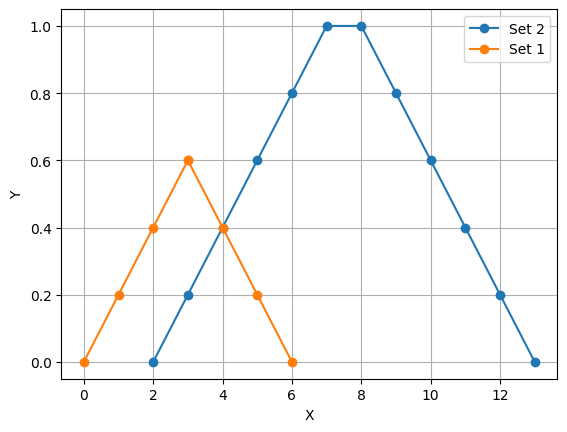

In [ ]:
collection2 = {
    0.6: [(3, 3)],
    0.4: [(2, 4)],
    0.2: [(1, 5)],
    0.0: [(0, 6)]
}

collection1 = {
    1.0: [(2, 3)],
    0.8: [(1.5, 3.5)],
    0.6: [(1, 4)],
    0.4: [(0.5, 4.5)],
    0.2: [(0, 5)],
    0.0: [(0, 6)]
}

col = {
    1.0: [(7, 8)],
    0.8: [(6, 9)],
    0.6: [(5, 10)],
    0.4: [(4, 11)],
    0.2: [(3, 12)],
    0.0: [(2, 13)]
}

AlphaFuzzyPlot(collection2, col)

In [ ]:
fuzzy_set1 = AlphaFuzzySet(col)
fuzzy_set2 = AlphaFuzzySet(collection2)

print("Fuzzy Set 1")
print("-------------------------------------------------------")

membership_degree = fuzzy_set1(2.5) #Uses the __call__ method for the membership degree
alpha_cut = fuzzy_set1[0.6]
fuzziness_value = fuzzy_set1.fuzziness()
hartley_entropy_value = fuzzy_set1.hartley()

print(f"Membership degree of 2.5: {membership_degree}")
print(f"α-cut for α = 0.6: {alpha_cut}")
print(f"Fuzziness of the fuzzy set: {fuzziness_value}")
print(f"Hartley entropy of the fuzzy set: {hartley_entropy_value}")

print("\n\nFuzzy Set 2")
print("-------------------------------------------------------")

membership_degree = fuzzy_set2(2.5)
alpha_cut = fuzzy_set2[0.6]
fuzziness_value = fuzzy_set2.fuzziness()
hartley_entropy_value = fuzzy_set2.hartley()

print(f"Membership degree of 2.5: {membership_degree}")
print(f"α-cut for α = 0.6: {alpha_cut}")
print(f"Fuzziness of the fuzzy set: {fuzziness_value}")
print(f"Hartley entropy of the fuzzy set: {hartley_entropy_value}")


Fuzzy Set 1
-------------------------------------------------------
Membership degree of 2.5: 0.0
α-cut for α = 0.6: [(5, 10)]
Fuzziness of the fuzzy set: 11.000000000000002
Hartley entropy of the fuzzy set: 6.015363119410166


Fuzzy Set 2
-------------------------------------------------------
Membership degree of 2.5: 0.4
α-cut for α = 0.6: [(3, 3)]
Fuzziness of the fuzzy set: 1.6
Hartley entropy of the fuzzy set: 1.098370619265935


#ALPHAFUZZYCOMBINATION CLASS IMPLEMENTATION:

We now introduce the AlphaFuzzyCombination class, a subclass of ContinuousFuzzyCombination. This class is designed to take two AlphaFuzzySet instances and a continuous, associative function as inputs, and produce a new AlphaFuzzySet that results from applying the function to the α-cuts of the input sets. The implementation leverages the property that for each continuous function 𝒇: ℝ<sup>2</sup>
-> ℝ the following holds:

∀𝒶 in [0,1], [𝒇’(𝓕<sub>1</sub>
, 𝓕<sub>2</sub>
)]<sub>𝒶</sub> = 𝒇( [𝓕<sub>1</sub>
]<sub>𝒶</sub>, [𝓕<sub>2</sub>
]<sub>𝒶</sub>)


This class will be tested with key operations to ensure its functionality.

For example, if we have two fuzzy sets
𝐴
and
𝐵 with membership functions
𝜇
(𝐴)
​
  and
𝜇
(𝐵)
​
 ,

* the membership function of the combined set
𝐶 using **addition** would be:

*μ* C(x)=*μ* A (x)+*μ* B (x)

* the membership function of the combined set
𝐶 using **multiplication** would be:

*μ* C(x)=*μ* A​(x)⋅*μ* B​ (x)







**Union and Intersection of Fuzzy Sets**

In fuzzy set theory, the union and intersection of two fuzzy sets are defined using the maximum and minimum operations, respectively.

#### Union (Maximum)
The union of two fuzzy sets $A$ and $B$ is a fuzzy set $C$ where the membership function $\mu_C(x)$ is the maximum of the membership functions of $A$ and $B$:<br>
>\[
$\mu_C(x) = \max(\mu_A(x), \mu_B(x))$
\]<br>
This means that for each element $x$, the membership degree in the union set $C$ is the highest membership degree that $x$ has in either set $A$ or set $B$.

#### Intersection (Minimum)
The intersection of two fuzzy sets $A$ and $B$ is a fuzzy set $D$ where the membership function $\mu_D(x)$ is the minimum of the membership functions of $A$ and $B$:<br>
>\[
$\mu_D(x) = \min(\mu_A(x), \mu_B(x))$
\]<br>
This means that for each element $x$, the membership degree in the intersection set $D$ is the lowest membership degree that $x$ has in either set $A$ or set $B$.

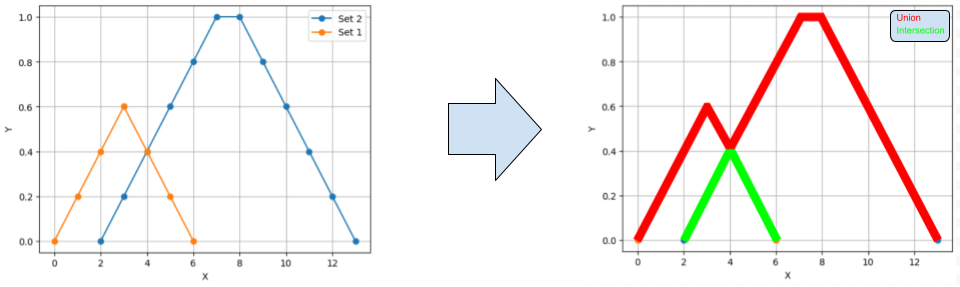

In [ ]:
class AlphaFuzzyCombination(ContinuousFuzzySet):
    def __init__(self, fuzzy_set1, fuzzy_set2, func):
        if not isinstance(fuzzy_set1, AlphaFuzzySet) or not isinstance(fuzzy_set2, AlphaFuzzySet):
            raise ValueError("Both inputs must be instances of AlphaFuzzySet")
        self.fuzzy_set1 = fuzzy_set1
        self.fuzzy_set2 = fuzzy_set2
        self.func = func  # Store the function for combination
        self.collection = self.combine_fuzzy_sets()

        # Calculate min and max for the combined fuzzy set
        self.min = min(fuzzy_set1.min, fuzzy_set2.min)
        self.max = max(fuzzy_set1.max, fuzzy_set2.max)

    def combine_fuzzy_sets(self):
        combined_collection = {}
        all_alphas = sorted(set(self.fuzzy_set1.collection.keys()).union(self.fuzzy_set2.collection.keys()), reverse=True)

        for alpha in all_alphas:
            intervals1 = self.fuzzy_set1.collection.get(alpha, [])
            intervals2 = self.fuzzy_set2.collection.get(alpha, [])

            if self.func == 'intersection':
                combined_intervals = self._intersect_intervals(intervals1, intervals2)
            elif self.func == 'union':
                combined_intervals = self._union_intervals(intervals1, intervals2)
            elif self.func == 'addition':
                combined_intervals = self._add_intervals(intervals1, intervals2)
            elif self.func == 'multiplication':
                combined_intervals = self._multiply_intervals(intervals1, intervals2)
            else:
                raise ValueError("Unsupported operation. Choose 'intersection', 'union', 'addition', or 'multiplication'.")

            if combined_intervals:
                combined_collection[alpha] = combined_intervals

        return combined_collection

    def _intersect_intervals(self, intervals1, intervals2):
        combined = []
        for start1, end1 in intervals1:
            for start2, end2 in intervals2:
                start = max(start1, start2)
                end = min(end1, end2)
                if start <= end:
                    combined.append((start, end))
        return combined

    def _union_intervals(self, intervals1, intervals2):
        combined = intervals1[:]
        for start2, end2 in intervals2:
            for i in range(len(combined)):
                start1, end1 = combined[i]
                if start2 <= end1 and end2 >= start1:
                    combined[i] = (min(start1, start2), max(end1, end2))
                    break
            else:
                combined.append((start2, end2))
        return combined

    def _add_intervals(self, intervals1, intervals2):
        combined = []
        for start1, end1 in intervals1:
            for start2, end2 in intervals2:
                combined.append((start1 + start2, end1 + end2))
        return combined

    def _multiply_intervals(self, intervals1, intervals2):
        combined = []
        for start1, end1 in intervals1:
            for start2, end2 in intervals2:
                products = [start1 * start2, start1 * end2, end1 * start2, end1 * end2]
                combined.append((min(products), max(products)))
        return combined

    def __call__(self, x):
        max_alpha = 0.0
        for alpha, intervals in self.collection.items():
            if any(start <= x <= end for start, end in intervals):
                max_alpha = max(max_alpha, alpha)
        return max_alpha

    def __getitem__(self, alpha):
        if alpha not in self.collection:
            raise KeyError(f"α-cut for α = {alpha} not found in the collection")
        return self.collection[alpha]

    def __eq__(self, other):
        if not isinstance(other, AlphaFuzzySet):
            return False
        return self.collection == other.collection

    def fuzziness(self):
        fuzziness = 0.0
        for alpha, intervals in self.collection.items():
            for start, end in intervals:
                fuzziness += (end - start) * alpha
        return fuzziness

    def hartley(self):
        entropy = 0.0
        for alpha, intervals in self.collection.items():
            for start, end in intervals:
                entropy += np.log2(end - start + 1) * alpha
        return entropy

# Example usage
fuzzy_set1 = AlphaFuzzySet({
    0.6: [(3, 3)],
    0.4: [(2, 4)],
    0.2: [(1, 5)],
    0.0: [(0, 6)]
})

fuzzy_set2 = AlphaFuzzySet({
    1.0: [(2, 3)],
    0.8: [(1.5, 3.5)],
    0.6: [(1, 4)],
    0.4: [(0.5, 4.5)],
    0.2: [(0, 5)],
    0.0: [(0, 6)]
})

def addition(x, y):
    return x + y

def multiplication(x, y):
    return x * y

combined_addition = AlphaFuzzyCombination(fuzzy_set1, fuzzy_set2, 'addition')
combined_multiplication = AlphaFuzzyCombination(fuzzy_set1, fuzzy_set2, 'multiplication')
combined_intersection = AlphaFuzzyCombination(fuzzy_set1, fuzzy_set2, 'intersection')
combined_union = AlphaFuzzyCombination(fuzzy_set1, fuzzy_set2, 'union')

print("Combined using Addition")
print(combined_addition.collection)
print("Combined using Multiplication")
print(combined_multiplication.collection)
print("Combined using Intersection")
print(combined_intersection.collection)
print("Combined using Union")
print(combined_union.collection)



Combined using Addition
{0.6: [(4, 7)], 0.4: [(2.5, 8.5)], 0.2: [(1, 10)], 0.0: [(0, 12)]}
Combined using Multiplication
{0.6: [(3, 12)], 0.4: [(1.0, 18.0)], 0.2: [(0, 25)], 0.0: [(0, 36)]}
Combined using Intersection
{0.6: [(3, 3)], 0.4: [(2, 4)], 0.2: [(1, 5)], 0.0: [(0, 6)]}
Combined using Union
{1.0: [(2, 3)], 0.8: [(1.5, 3.5)], 0.6: [(1, 4)], 0.4: [(0.5, 4.5)], 0.2: [(0, 5)], 0.0: [(0, 6)]}


To have a graphical idea of the results of these operations, we also defined the following function, that will plot them.

Coord x e y [3, 3, 2, 4, 1, 5, 0, 6] [0.6, 0.4, 0.2, 0.0]
Coords [(0, 0.0), (1, 0.2), (2, 0.4), (3, 0.6), (3, 0.6), (4, 0.4), (5, 0.2), (6, 0.0)]


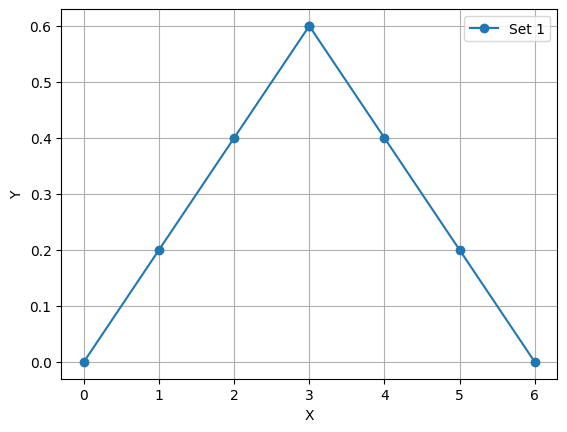

Coord x e y [2, 3, 1.5, 3.5, 1, 4, 0.5, 4.5, 0, 5, 0, 6] [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
Coords [(0, 0.0), (0, 0.2), (0.5, 0.4), (1, 0.6), (1.5, 0.8), (2, 1.0), (3, 1.0), (3.5, 0.8), (4, 0.6), (4.5, 0.4), (5, 0.2), (6, 0.0)]


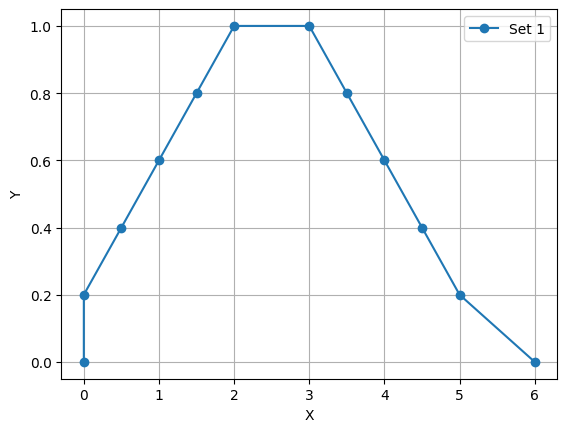

Coord x e y [4, 7, 2.5, 8.5, 1, 10, 0, 12] [0.6, 0.4, 0.2, 0.0]
Coords [(0, 0.0), (1, 0.2), (2.5, 0.4), (4, 0.6), (7, 0.6), (8.5, 0.4), (10, 0.2), (12, 0.0)]


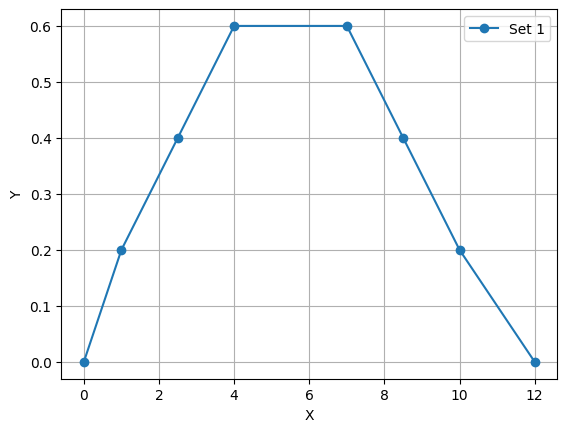

Coord x e y [3, 12, 1.0, 18.0, 0, 25, 0, 36] [0.6, 0.4, 0.2, 0.0]
Coords [(0, 0.0), (0, 0.2), (1.0, 0.4), (3, 0.6), (12, 0.6), (18.0, 0.4), (25, 0.2), (36, 0.0)]


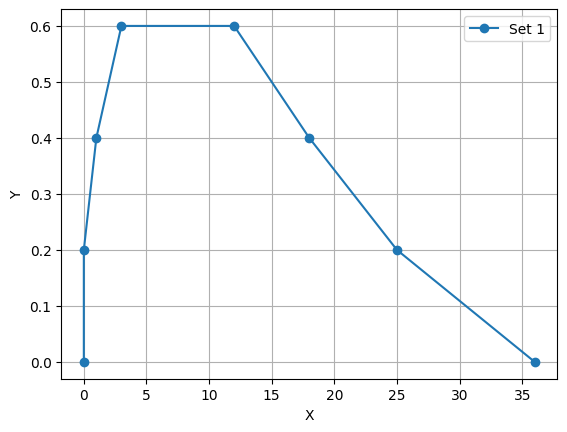

In [ ]:
def plot_coordinates(x_coordinates, y_coordinates, label='Set'):
    coordinates = combine_coordinates(x_coordinates, y_coordinates)
    x_values = [coord[0] for coord in coordinates]
    y_values = [coord[1] for coord in coordinates]
    plt.plot(x_values, y_values, marker='o', label=label)

def AlphaFuzzyPlot(collection1, collection2=None):
    x_coordinates1, y_coordinates1 = extract_coordinates(collection1)
    plot_coordinates(x_coordinates1, y_coordinates1, label='Set 1')

    if collection2:
        x_coordinates2, y_coordinates2 = extract_coordinates(collection2)
        plot_coordinates(x_coordinates2, y_coordinates2, label='Set 2')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.legend()
    plt.show()

AlphaFuzzyPlot(combined_intersection.collection)
AlphaFuzzyPlot(combined_union.collection)
AlphaFuzzyPlot(combined_addition.collection)
AlphaFuzzyPlot(combined_multiplication.collection)